Updated model to modify for normalization N and baseline B.

In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [9]:
from src.RealDataReplication import RealDataReplicationDeconvolution
from src.config import load_configs_by_config_type

config, _ = load_configs_by_config_type('shared')

real_deconv1 = RealDataReplicationDeconvolution(config, replicate=1)

In [869]:
G = real_deconv1.normalized_occupancy.T.values

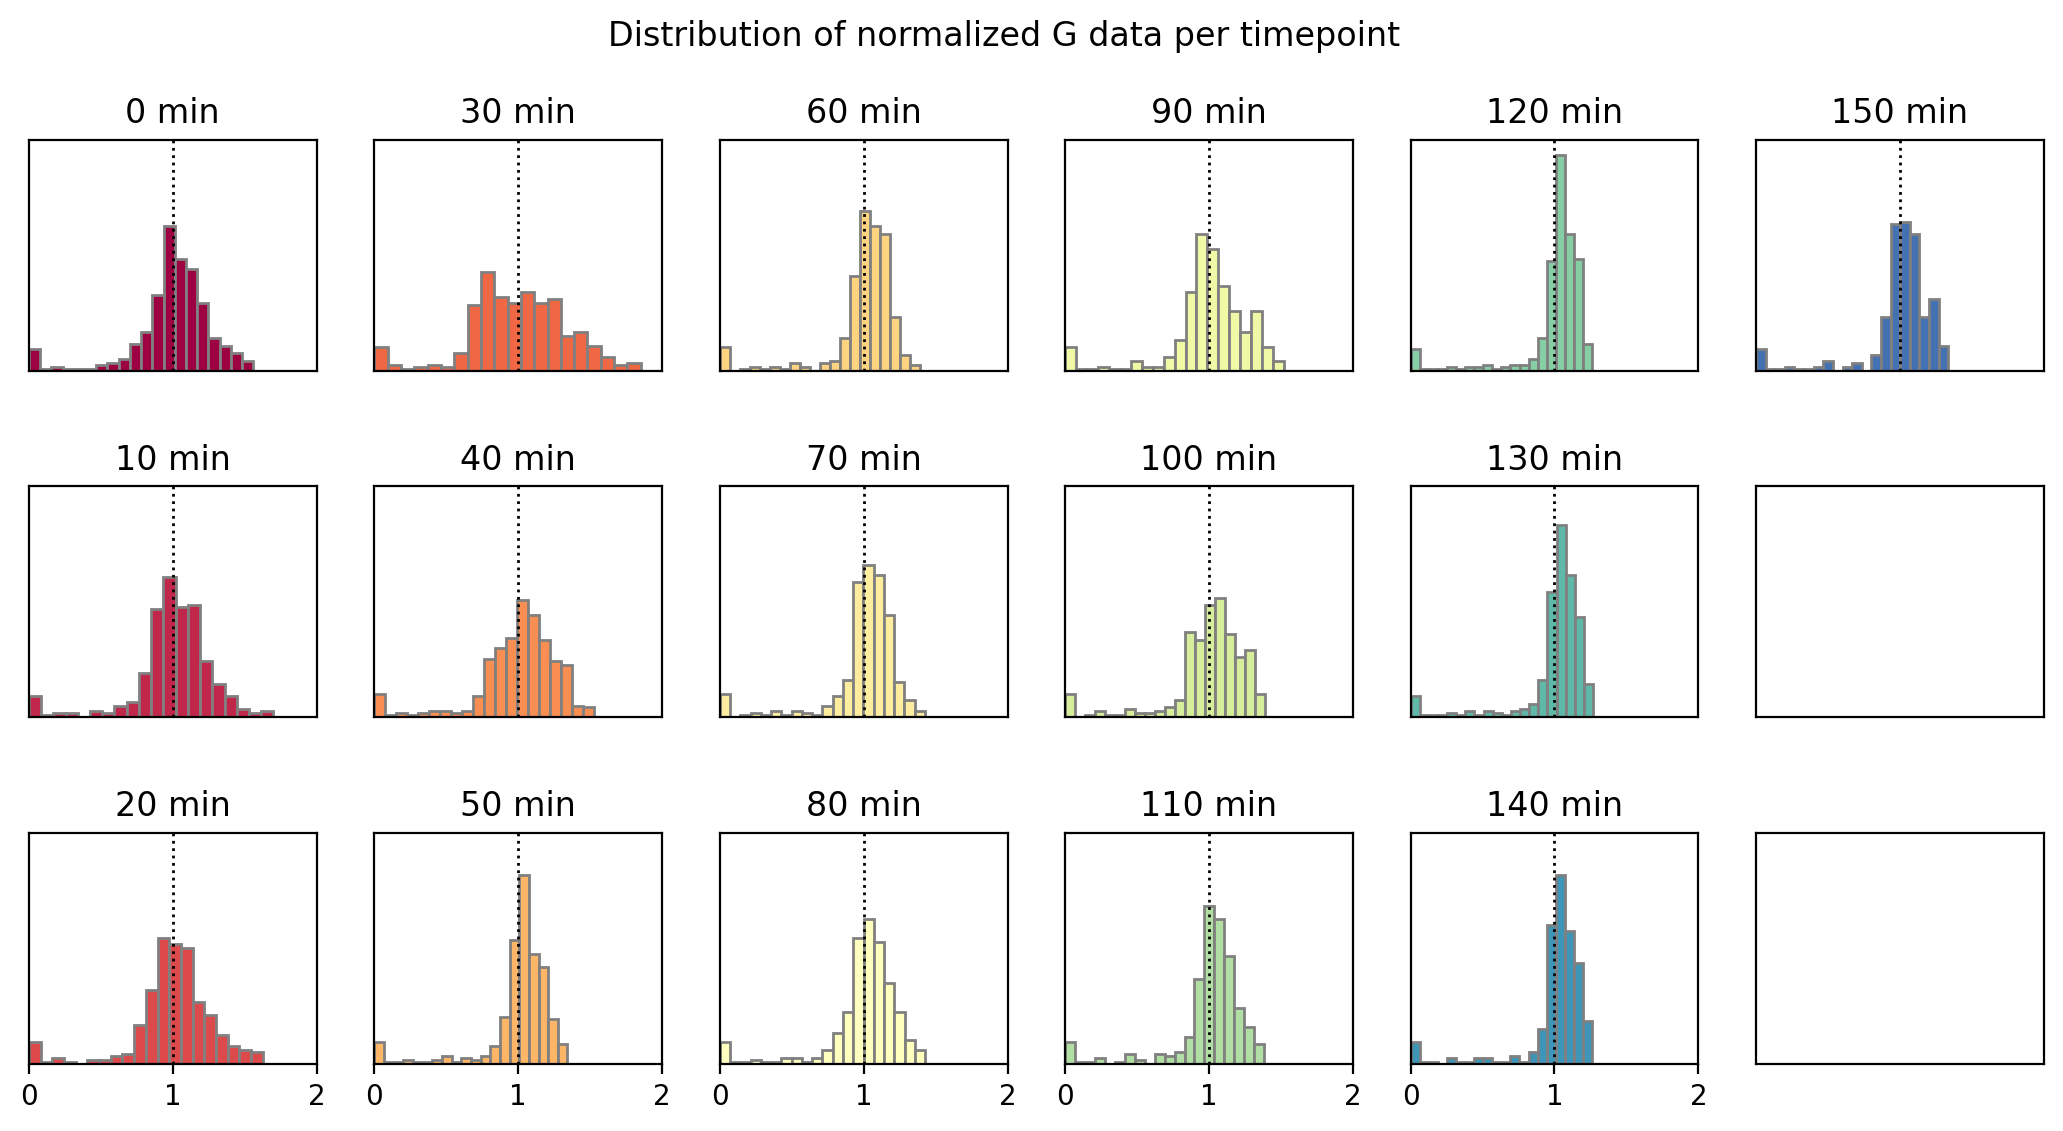

In [870]:
from src.RealDataReplication import plot_histogram_occupancies_G

plot_histogram_occupancies_G(config, G)

###### 

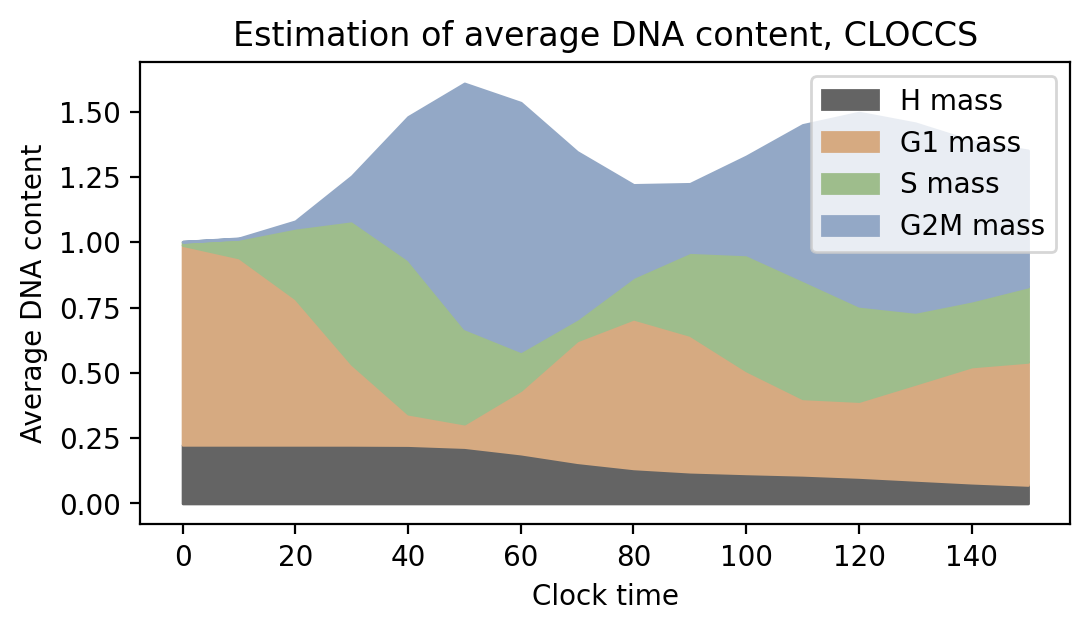

In [857]:
from src.RealDataReplication import compute_N

average_DNA, N = compute_N(config)
B = np.diag(G[0])

In [323]:
from src.replication_deconvolution_solver import deconvolve_replication

F = deconvolve_replication(config, H, G, N, B)

0/368 - 00:00:00.000
50/368 - 00:00:04.954
100/368 - 00:00:09.225
150/368 - 00:00:14.031
200/368 - 00:00:18.068
250/368 - 00:00:22.821
300/368 - 00:00:26.912
350/368 - 00:00:31.789


In [852]:
from src.RealDataReplication import plot_heatmaps

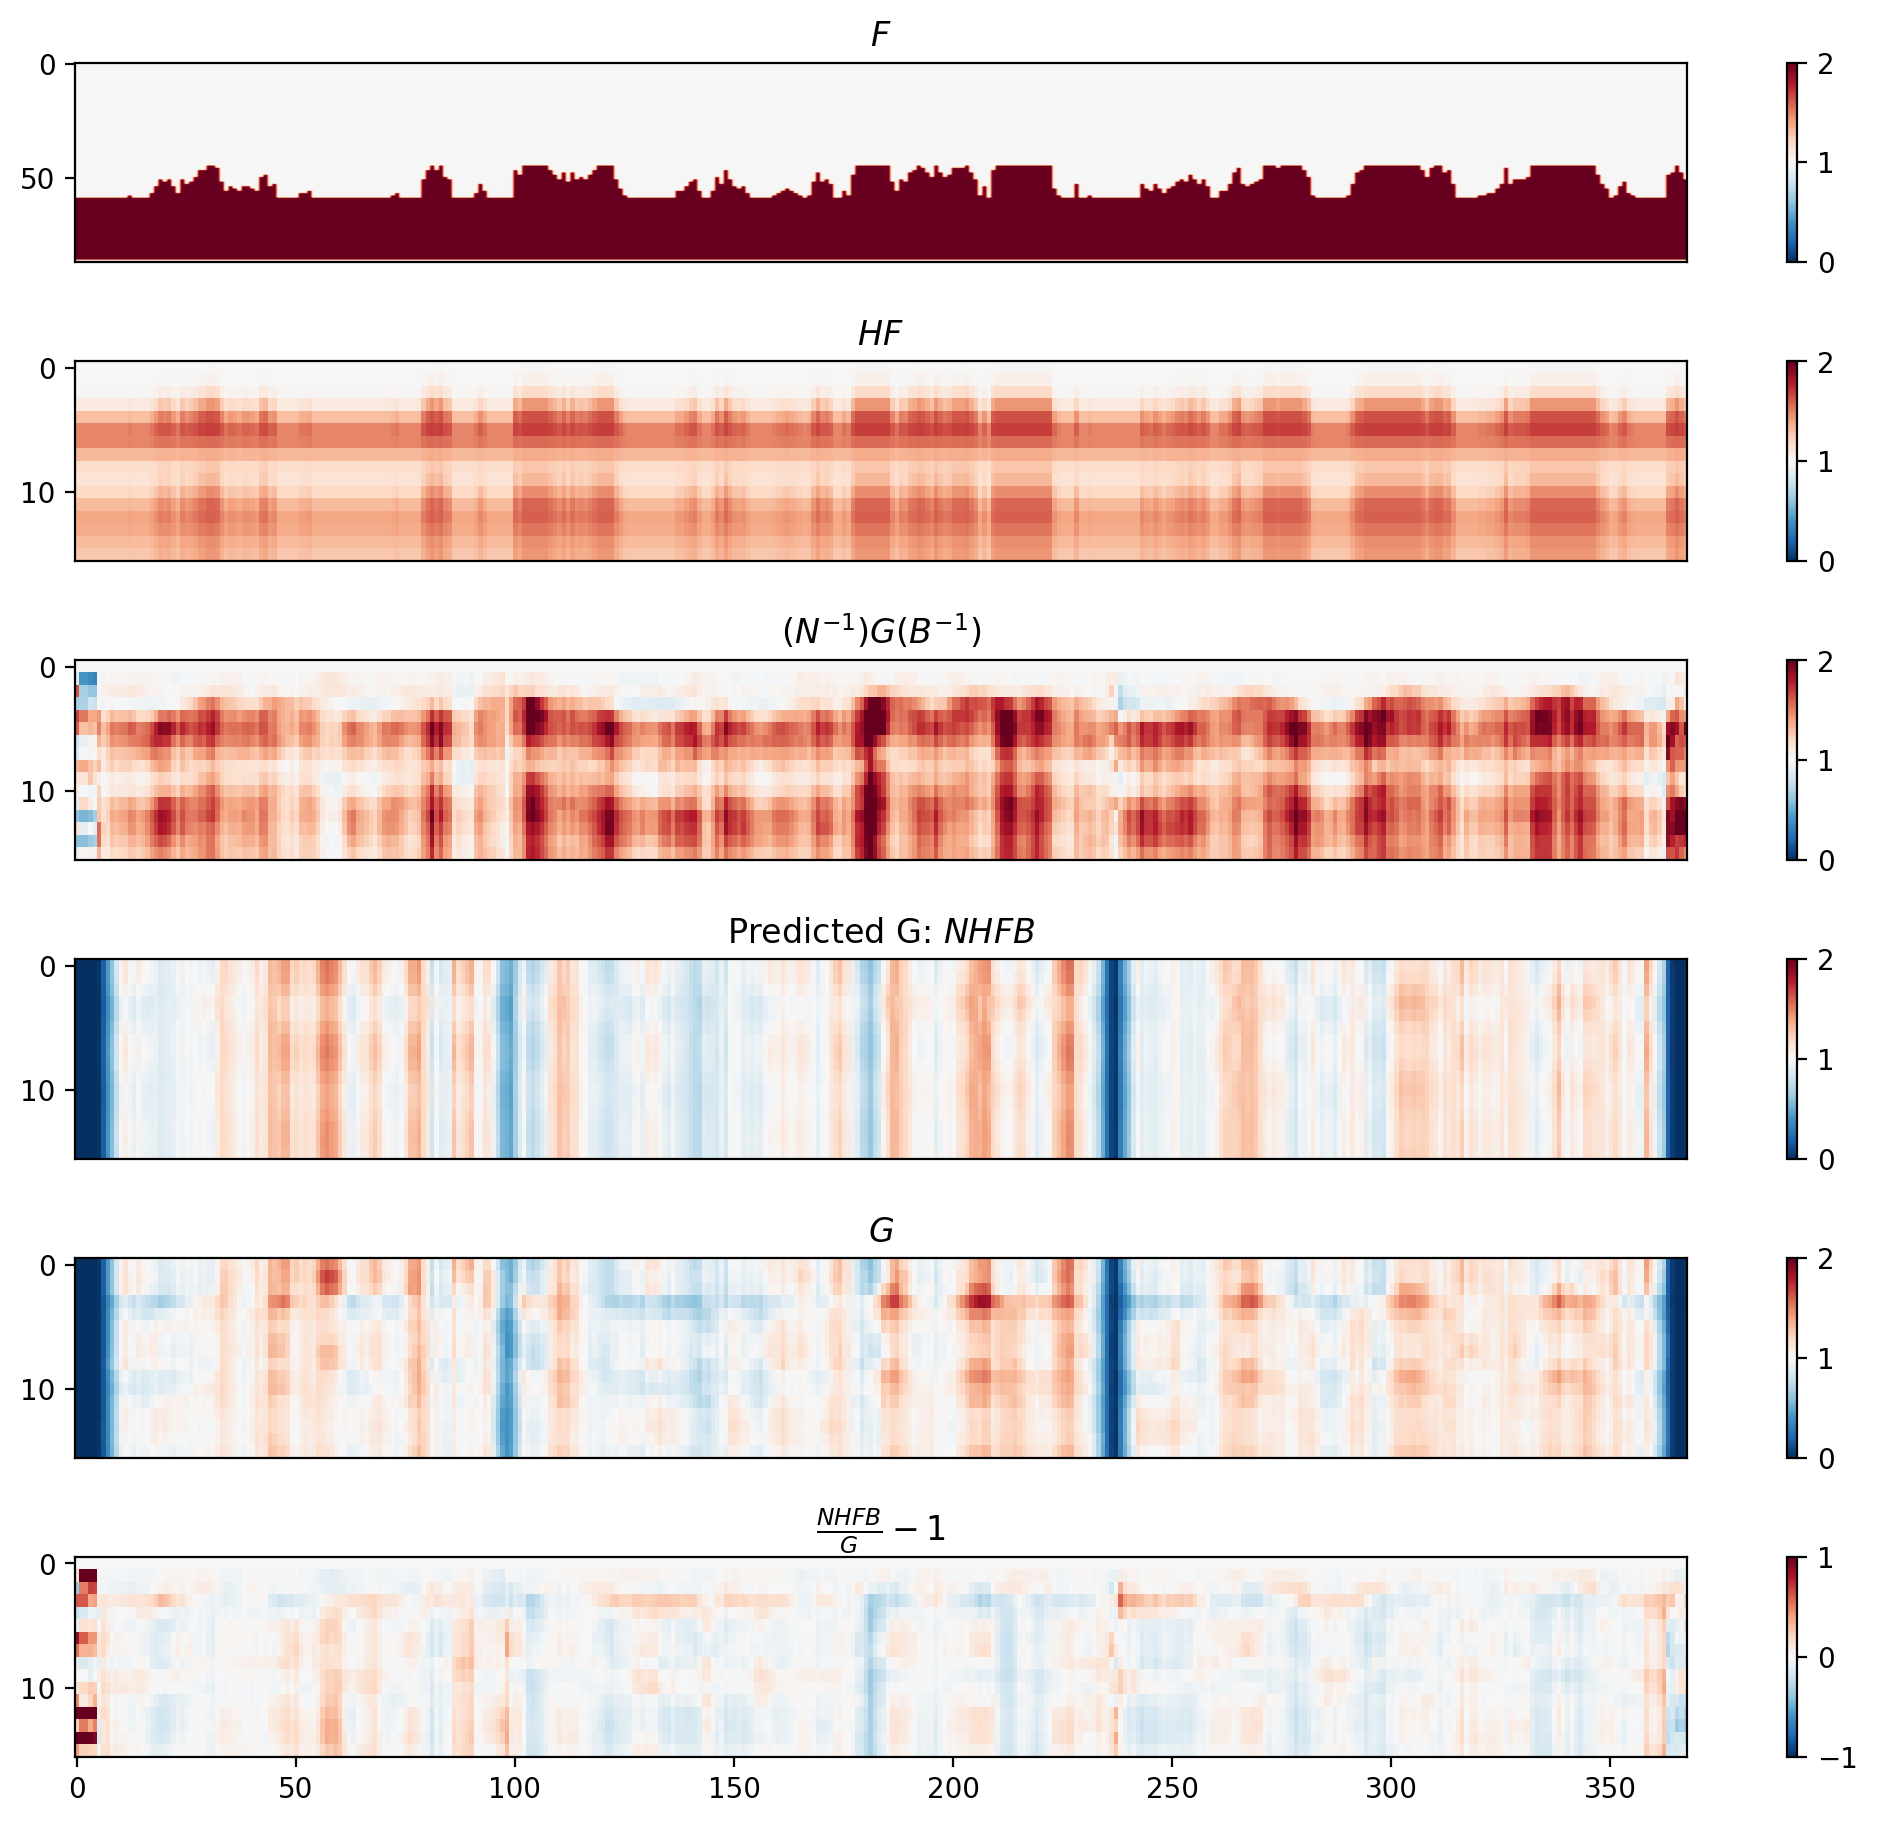

In [853]:
plot_heatmaps(N, F, H, B, G)

In [326]:
updated_F = deconvolve_replication(config, H, G, updated_N, B)

0/368 - 00:00:00.000
50/368 - 00:00:04.064
100/368 - 00:00:08.816
150/368 - 00:00:12.944
200/368 - 00:00:17.753
250/368 - 00:00:21.732
300/368 - 00:00:26.466
350/368 - 00:00:30.498


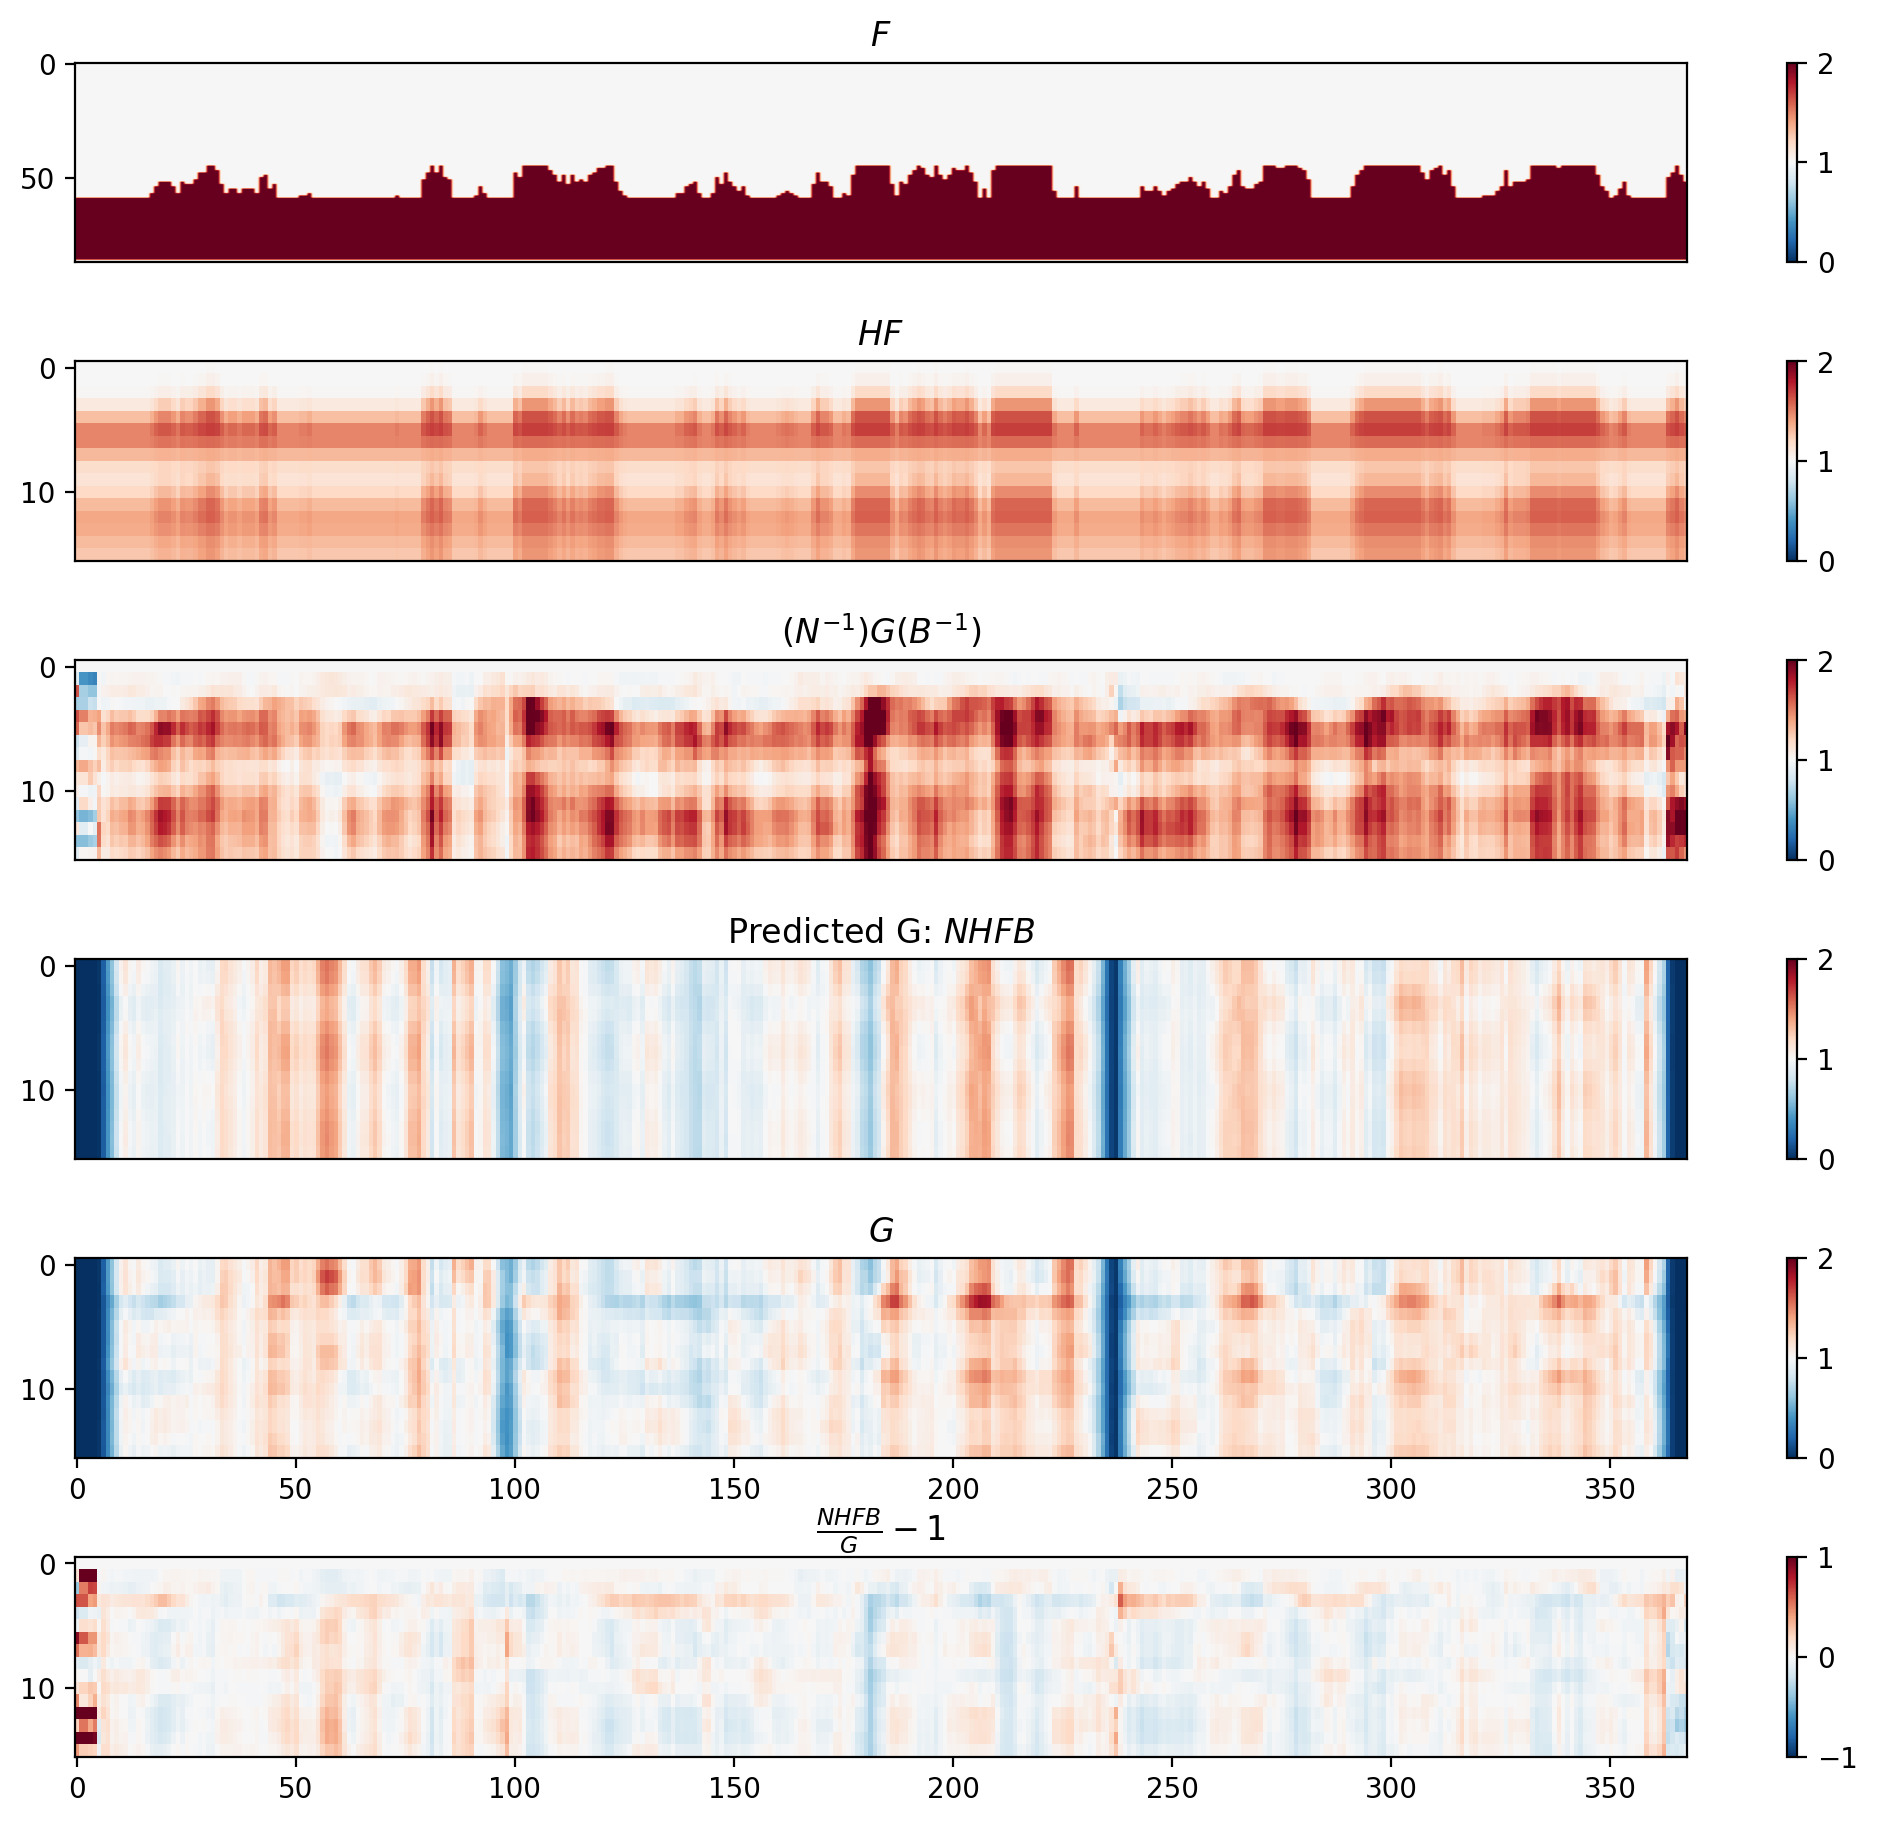

In [341]:
plot_heatmaps(updated_N, updated_F, H, B, G)

In [371]:
from scipy.stats.distributions import norm

def create_norm_avg_replication_curve(config, H):
    n, m = H.shape
    s_indices = config.get_Hpositions_for_phase('S')
    mid_s = s_indices[len(s_indices)//2]

    xs = np.arange(0, m, 1)
    ys = norm.cdf(xs, loc=mid_s, scale=3)+1
    ys[-1] = 1
    return ys


In [416]:
simulated_avg_F = create_norm_avg_replication_curve(config, H)
sim_avg_copy_in_G = H@simulated_avg_F

(0.5, 1.7)

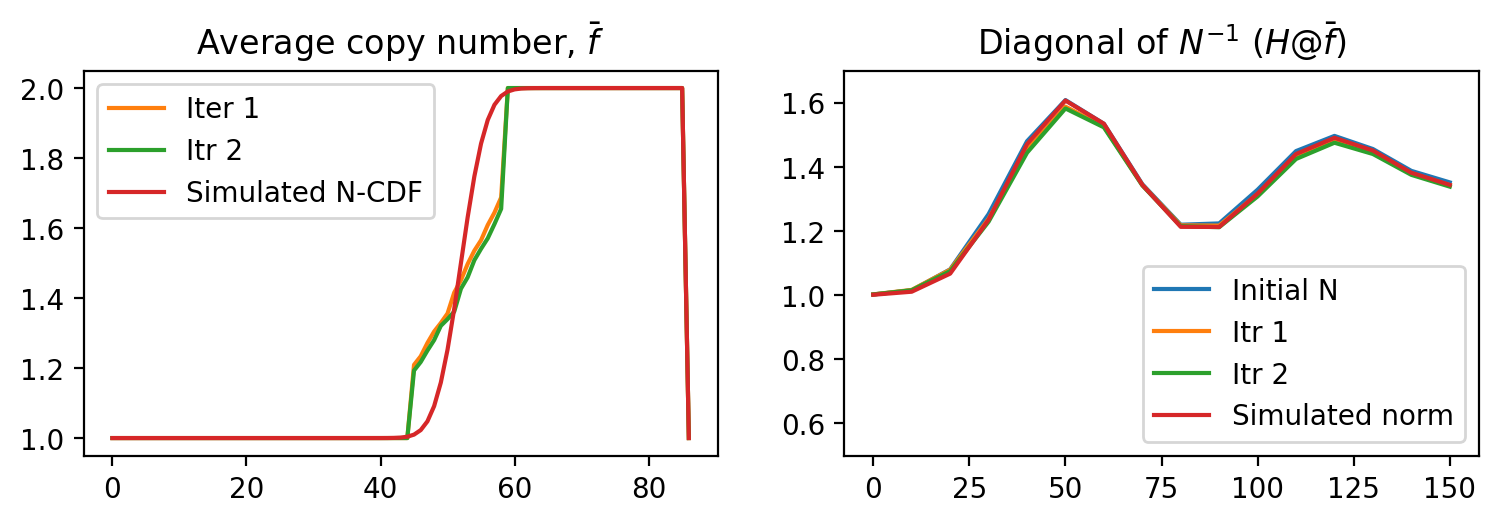

In [443]:

plt.figure(figsize=(9, 2.5))

plt.subplot(1, 2, 1)
plt.plot(1, 1)
plt.plot(F.mean(axis=1), label="Iter 1")
plt.plot(updated_F.mean(axis=1), label="Itr 2")
plt.plot(simulated_avg_F, label="Simulated N-CDF")
plt.legend()
plt.title("Average copy number, $\\bar{f}$")

plt.subplot(1, 2, 2)
plt.plot(tps, average_DNA, label="Initial N")
plt.plot(tps, H@F.mean(axis=1), label="Itr 1")
plt.plot(tps, H@updated_F.mean(axis=1), label="Itr 2")
plt.plot(tps, sim_avg_copy_in_G, label="Simulated norm")
plt.legend()
plt.title("Diagonal of $N^{-1}$ ($H@\\bar{f}$)")
plt.ylim(0.5, 1.7)

In [377]:
simulated_N_F = deconvolve_replication(config, H, G, simulated_N, B)


0/368 - 00:00:00.000
50/368 - 00:00:05.173
100/368 - 00:00:09.252
150/368 - 00:00:13.905
200/368 - 00:00:17.875
250/368 - 00:00:21.812
300/368 - 00:00:26.392
350/368 - 00:00:30.272


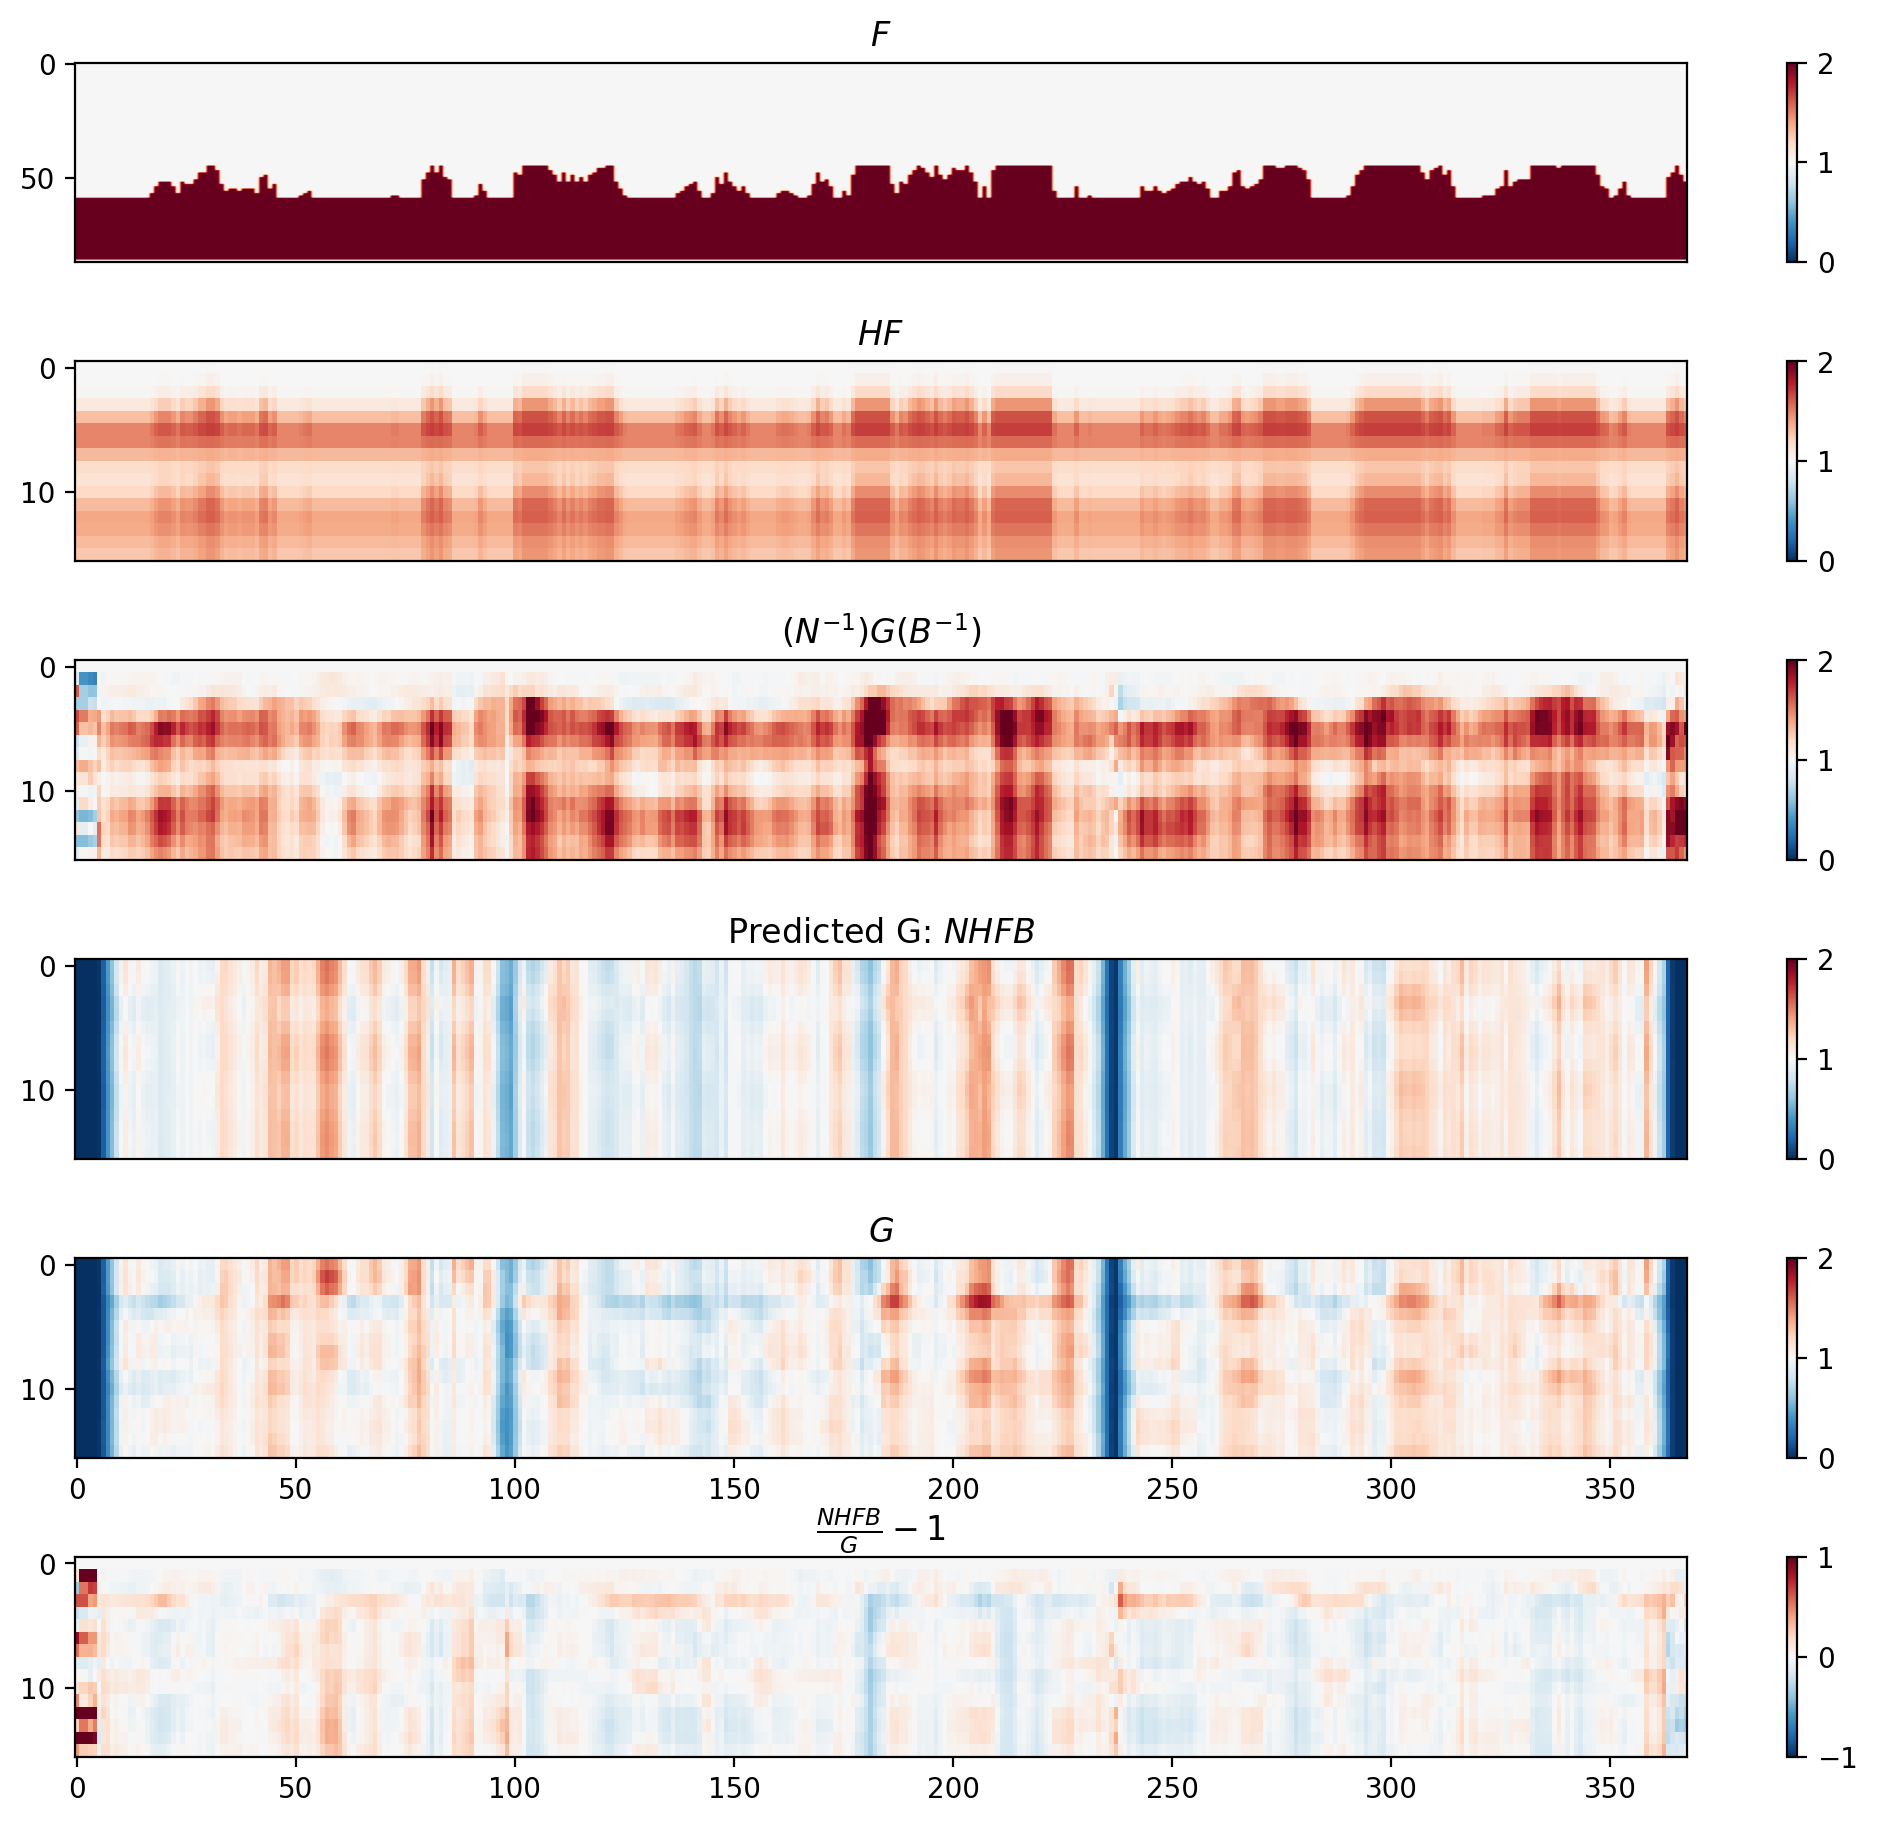

In [378]:
plot_heatmaps(simulated_N, simulated_N_F, H, B, G)

In [423]:
config, _ = load_configs_by_config_type('shared')
real_deconv_chr4 = RealDataReplicationDeconvolution(config, replicate=1, chr=4)

In [831]:
from src.timer import Timer

timer = Timer()
indices = range(0, G.shape[1])
selected_F = F[:, indices]
selected_G = G[:, indices]
selected_B = B[indices, :][:, indices]
prev_F = selected_F

iterations = 10
smoothness_weight = 1

F_updates = np.zeros((iterations, *prev_F.shape))
iterative_rns = np.zeros(iterations)
iterative_sns = np.zeros(iterations)

for i in range(0, iterations):
    print("Iteration", i)
    smoothing_update_F, avg_rn, avg_sn = deconvolve_replication(config, H, selected_G,
        N, selected_B, prev_F=prev_F, timer=timer, smoothness_weight=smoothness_weight)
    prev_F = smoothing_update_F
    F_updates[i] = smoothing_update_F
    iterative_rns[i] = avg_rn
    iterative_sns[i] = avg_sn

timer.print_time("Overall time elapsed")

Iteration 0
0/368 - 00:00:00.065
50/368 - 00:00:05.490
100/368 - 00:00:09.283
150/368 - 00:00:13.054
200/368 - 00:00:17.801
250/368 - 00:00:21.747
300/368 - 00:00:26.489
350/368 - 00:00:30.223
Iteration 1
0/368 - 00:00:31.639
50/368 - 00:00:36.337
100/368 - 00:00:40.090
150/368 - 00:00:43.862
200/368 - 00:00:48.615
250/368 - 00:00:52.441
300/368 - 00:00:56.464
350/368 - 00:01:01.365
Iteration 2
0/368 - 00:01:02.845
50/368 - 00:01:07.044
100/368 - 00:01:12.130
150/368 - 00:01:16.320
200/368 - 00:01:21.774
250/368 - 00:01:25.792
300/368 - 00:01:29.846
350/368 - 00:01:34.940
Iteration 3
0/368 - 00:01:36.433
50/368 - 00:01:40.431
100/368 - 00:01:45.617
150/368 - 00:01:49.673
200/368 - 00:01:53.717
250/368 - 00:01:58.622
300/368 - 00:02:02.468
350/368 - 00:02:08.498
Iteration 4
0/368 - 00:02:09.962
50/368 - 00:02:13.932
100/368 - 00:02:18.761
150/368 - 00:02:23.032
200/368 - 00:02:27.028
250/368 - 00:02:32.311
300/368 - 00:02:37.168
350/368 - 00:02:42.143
Iteration 5
0/368 - 00:02:43.604
50

Text(0.5, 1.0, 'Smoothness=1')

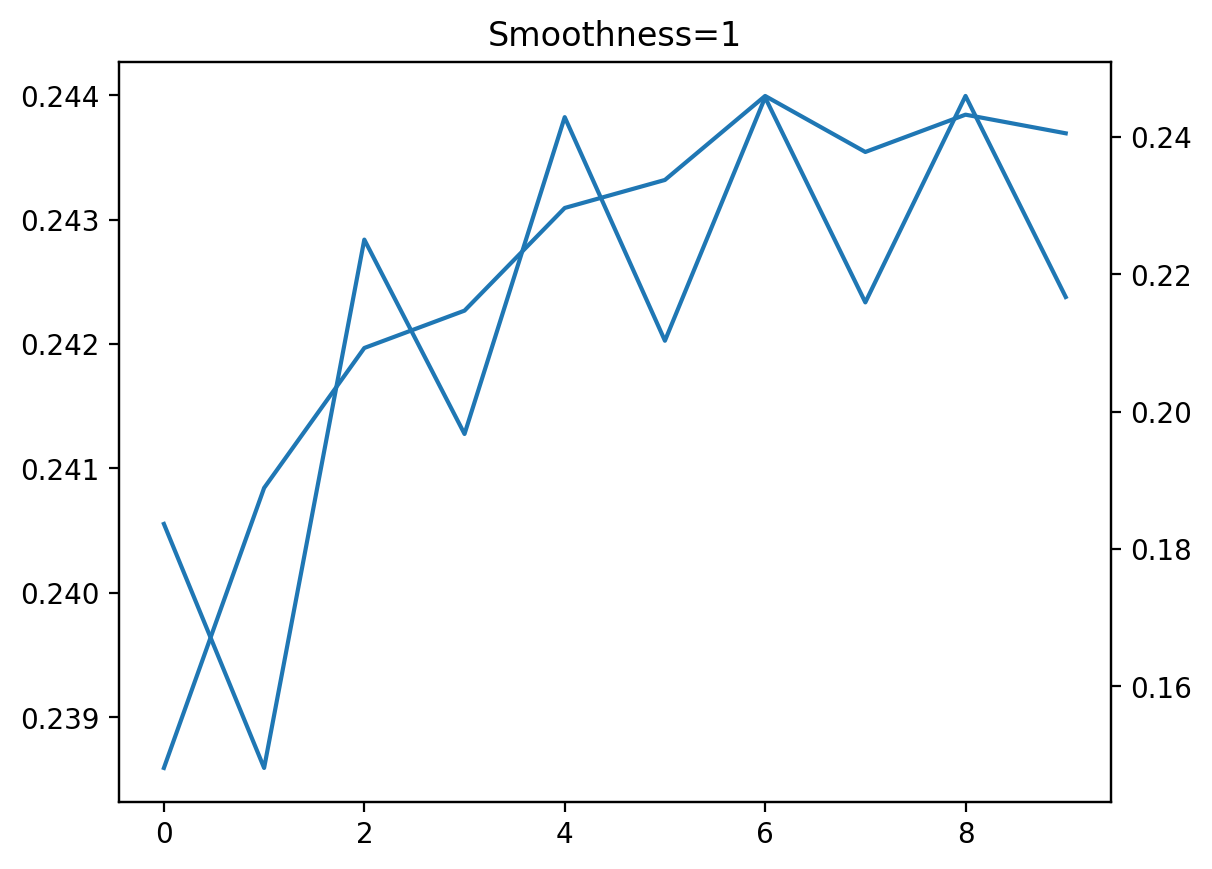

In [841]:
plt.plot(iterative_rns)
ax2 = plt.gca().twinx()
ax2.plot(iterative_sns)
plt.title(f"Smoothness={smoothness_weight}")


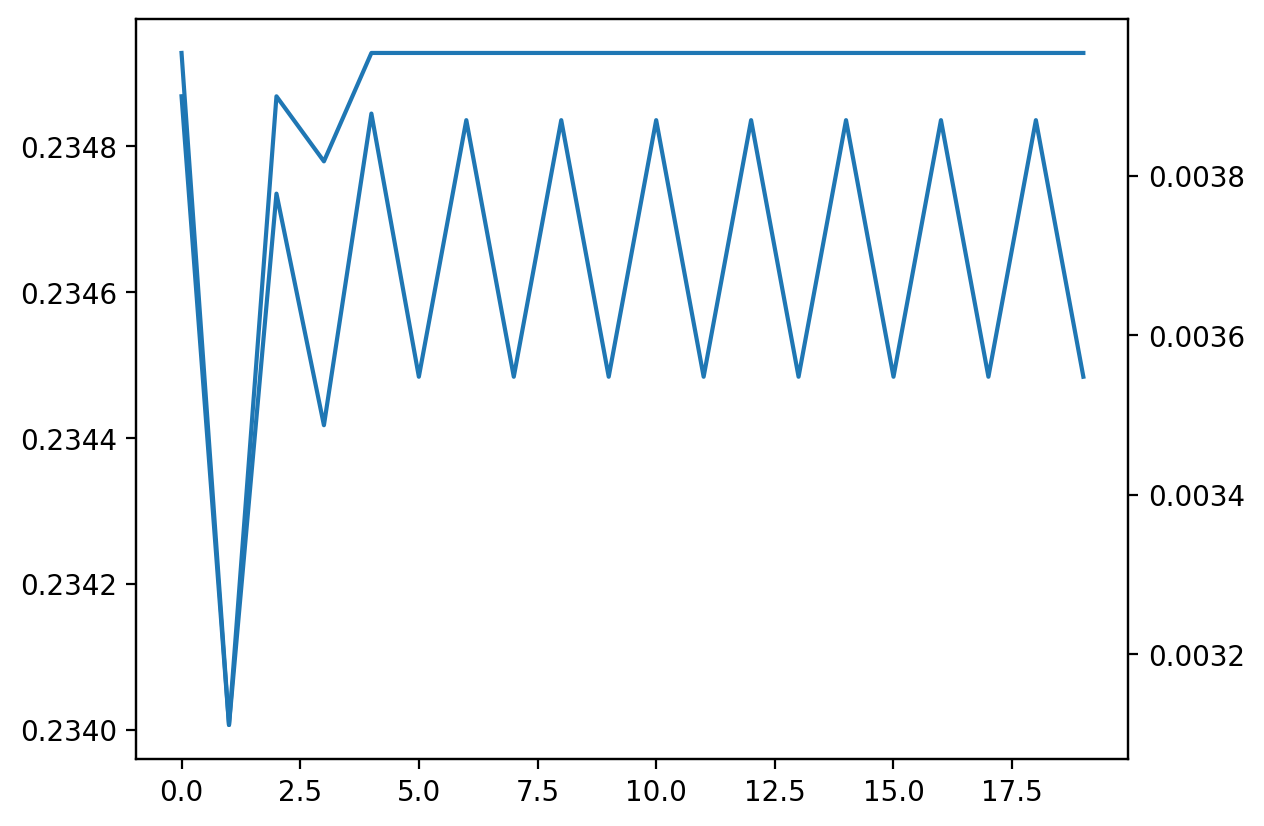

In [830]:
plt.plot(iterative_rns)
ax2 = plt.gca().twinx()
ax2.plot(iterative_sns)
plt.title("Smoothness=0.01")


In [833]:
def plot_updated_F_comparison(selected_F, updated_Fs, i):
    
    updated_F = updated_Fs[i]
    
    fig = plt.figure(figsize=(13, 5))
    plt.subplot(4, 1, 1)
    plt.imshow(selected_F, aspect='auto', interpolation='none', cmap='RdBu_r', 
               vmin=0, vmax=2)
    plt.xticks([])
    plt.ylim(60, 40)
    plt.title("Start")

    plt.subplot(4, 1, 2)
    plt.imshow(updated_Fs[-1], aspect='auto', interpolation='none', cmap='RdBu_r', 
               vmin=0, vmax=2)
    plt.xticks([])
    plt.ylim(60, 40)
    plt.title(f"End (iteration={len(updated_Fs)})")

    plt.subplot(4, 1, 3)
    plt.imshow(updated_F, aspect='auto', interpolation='none', cmap='RdBu_r',
                              vmin=0, vmax=2)
    plt.ylim(60, 40)
    plt.xticks([])
    plt.title(f"Iteration: {i}")
    
    plt.subplot(4, 1, 4)
    plt.imshow(updated_F-selected_F, aspect='auto',
               cmap='RdBu_r', interpolation='none', vmin=-1, vmax=1)
    plt.ylim(60, 40)
    plt.xticks([])    
    plt.title(f"Difference")
    
    plt.subplots_adjust(hspace=0.5)
    
    return fig

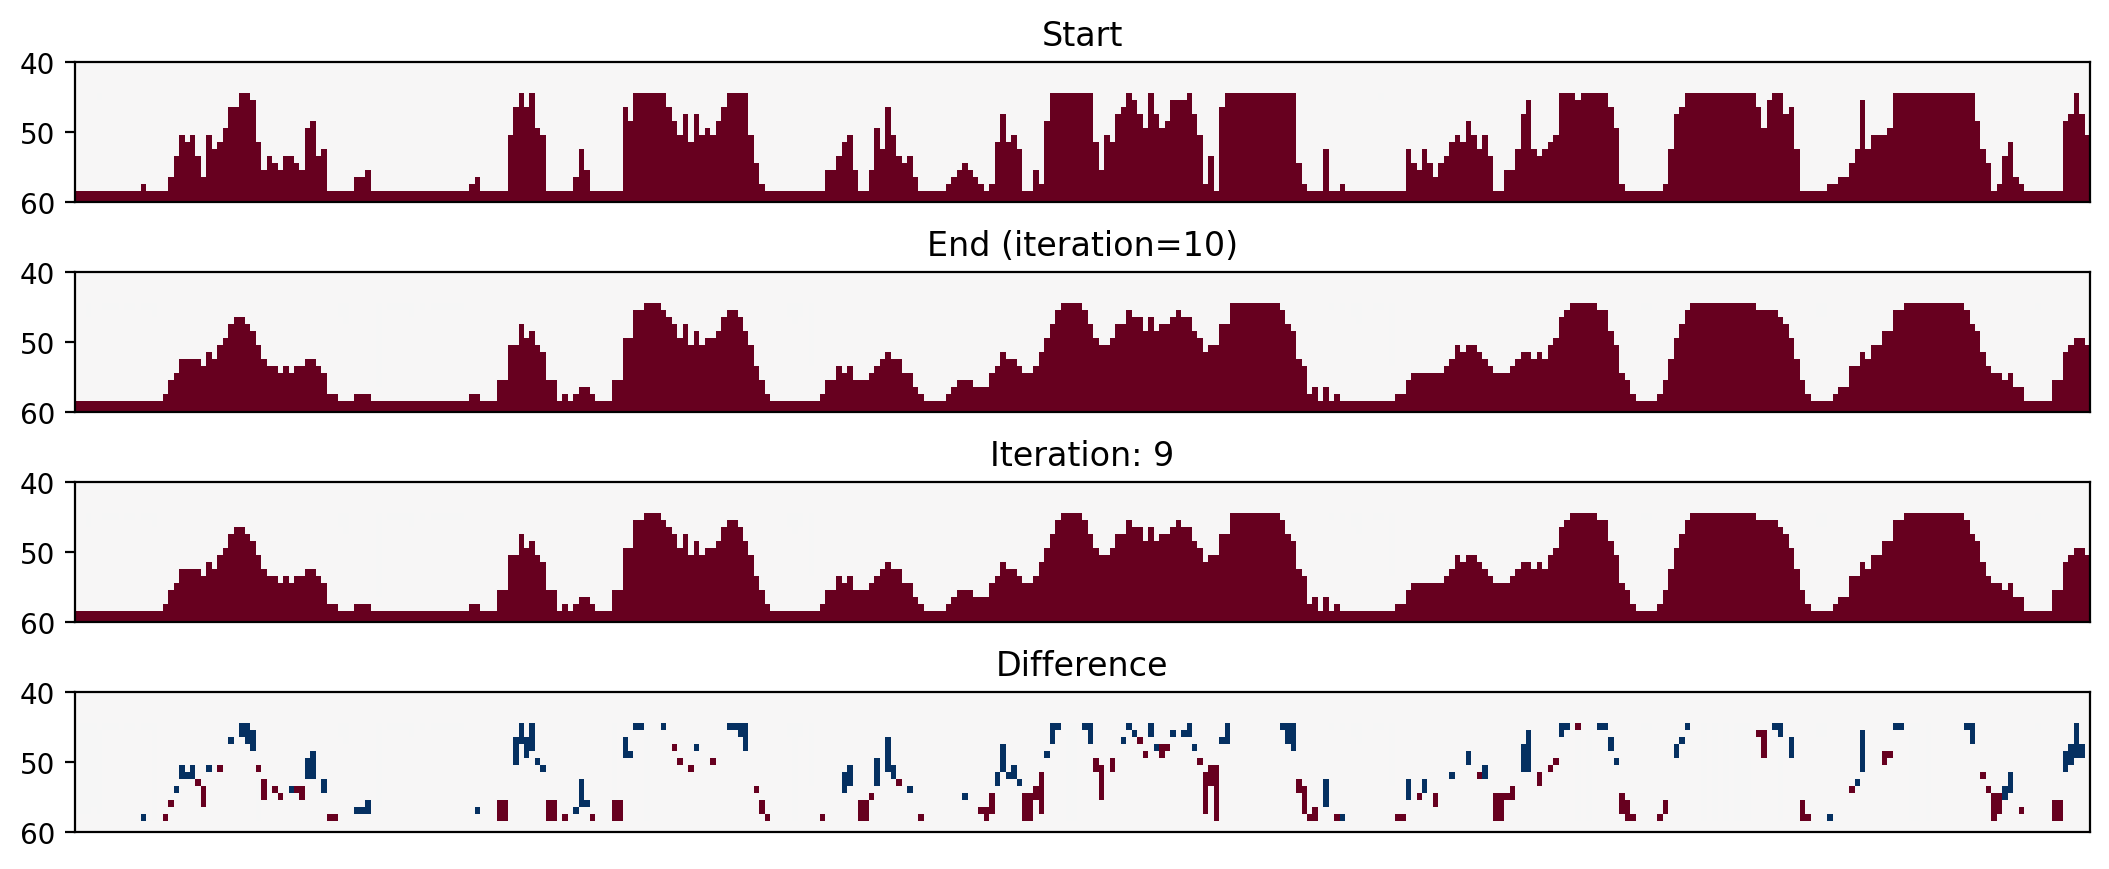

In [834]:
fig = plot_updated_F_comparison(selected_F, F_updates, 9)

In [835]:
for i in range(iterations-1):
    fig = plot_updated_F_comparison(selected_F, F_updates, i)
    plt.savefig(f'output/tmp/f_smooth_updates_{i}.png')
    plt.close(fig)
    

In [836]:
from src.mnase_total_curve_debugging import create_animation, show_gif

create_animation(list(range(iterations-1)), 'output/tmp/f_smooth_animation.gif', 'output/tmp/',
    'f_smooth_updates_')


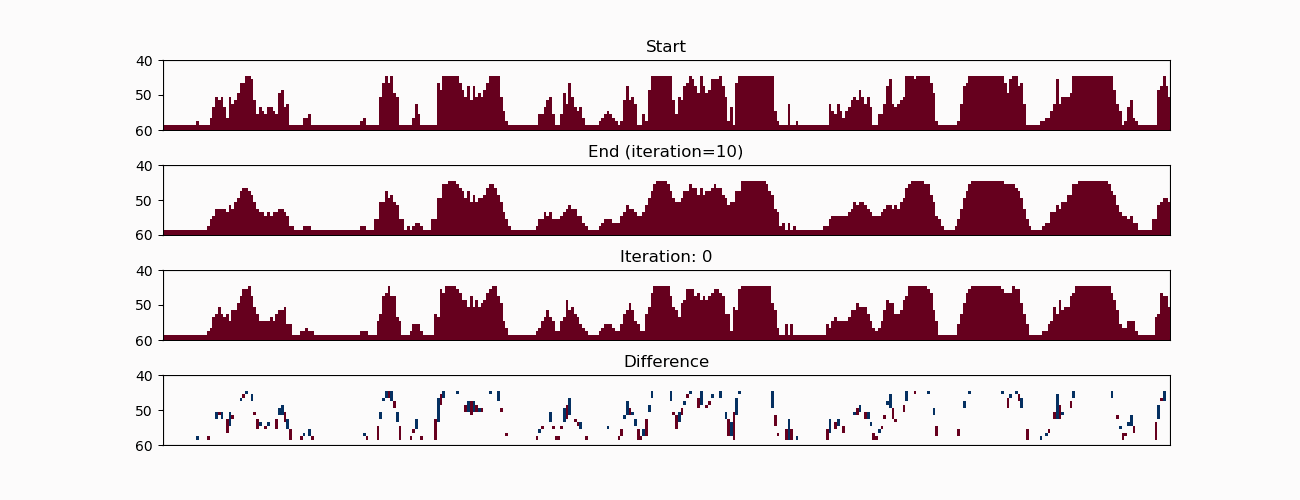

In [837]:
show_gif('output/tmp/f_smooth_animation.gif')

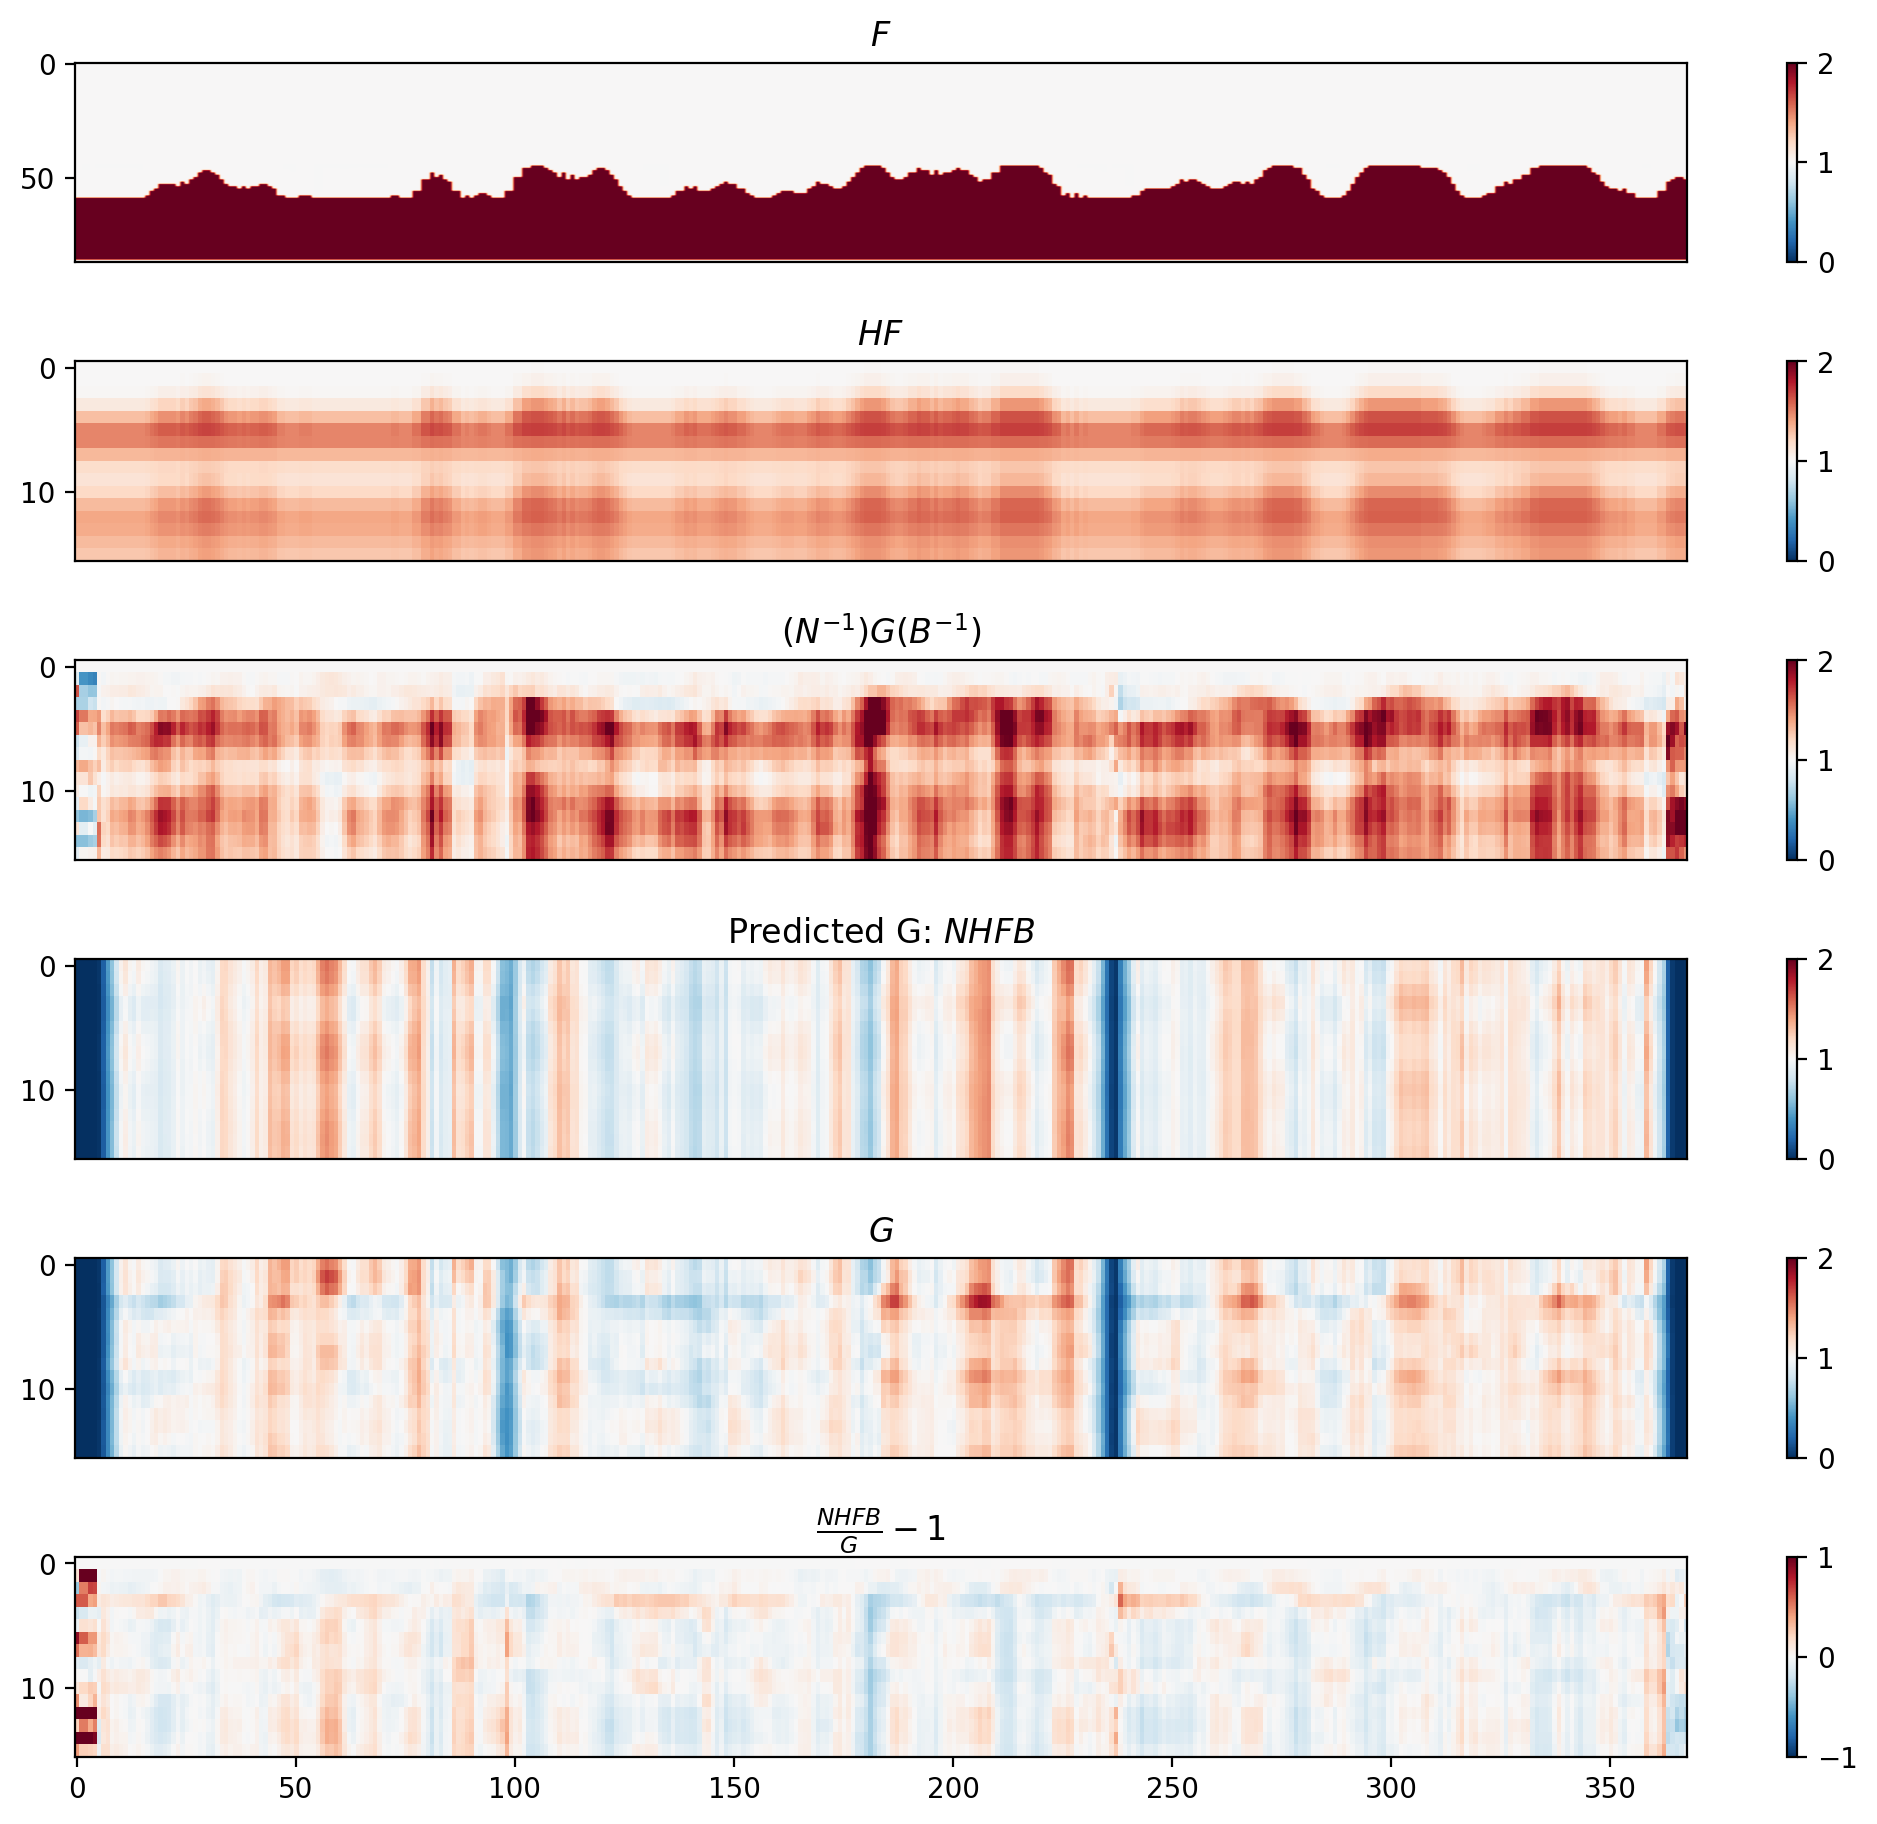

In [842]:
plot_heatmaps(N, F_updates[-1], H, B, G)